In [2]:
%%capture
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install pennylane
!pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 59.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 94.7 MB/s eta 0:00:00:00:0100:01


In [4]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import timedelta

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import *
from tqdm.auto import tqdm

import pennylane as qml
from torchinfo import summary

# Precision settings
np.set_printoptions(precision=3)
torch.set_printoptions(precision=3)

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 6  
EPOCHS = 15
LR = 0.00005      
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [9]:
TRAIN_DIR = "/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train"
TEST_DIR  = "/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test"

In [10]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [11]:
# ✅ UPDATED: Using ImageFolder instead of custom CSV-based Dataset
# Dataset structure: train/benign, train/malignant, test/benign, test/malignant
full_train = ImageFolder(root=TRAIN_DIR, transform=transform)

CLASSES = full_train.classes          # ['benign', 'malignant']
num_classes = len(CLASSES)
print(f"Classes: {CLASSES}")
print(f"Total train images: {len(full_train)}")

Classes: ['benign', 'malignant']
Total train images: 9605


In [12]:
# ✅ UPDATED: Split train into train (85%) + val (15%), use provided test folder directly
train_size = int(0.85 * len(full_train))
val_size   = len(full_train) - train_size

train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

# Use the provided test folder directly
test_dataset = ImageFolder(root=TEST_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 8164 | Val: 1441 | Test: 1000


In [13]:
n_qubits = 2
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    # 🔹 DATA ENCODING (Angle Encoding)
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # 🔹 VARIATIONAL LAYERS
    for l in range(n_layers):

        # Rotation layer
        for i in range(n_qubits):
            qml.RX(weights[l, i], wires=i)
            qml.RZ(weights[l, i], wires=i)

        # 🔹 ENTANGLEMENT (chain + ring)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])  # ring

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_layers, n_qubits))

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):
            out = quantum_circuit(x[i], self.weights)
            out = torch.stack(out).float()
            outputs.append(out)
        return torch.stack(outputs)

In [14]:
class HybridMobileNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        base = models.mobilenet_v2(weights="DEFAULT")
        self.features = base.features

        # Freeze 50%
        freeze_layers = len(self.features)//2
        for i in range(freeze_layers):
            for p in self.features[i].parameters():
                p.requires_grad = False

        # Quantum branch
        self.q_branch = nn.Sequential(
            nn.Conv2d(160, 40, 1),
            nn.BatchNorm2d(40),
            nn.ReLU(),

            nn.Conv2d(40, 8, 3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.q_fc = nn.Linear(8, n_qubits)
        self.quantum = QuantumLayer()

        # Classical enhancement
        self.extra = nn.Sequential(
            nn.Conv2d(1280,128,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.final_fc = nn.Linear(64 + n_qubits, num_classes)

    def forward(self,x):
        x = self.features[:17](x)

        # Quantum
        q = self.q_branch(x)
        q = torch.flatten(q,1)
        q = torch.tanh(self.q_fc(q))
        q = self.quantum(q)

        # Classical
        c = self.features[17:](x)
        c = self.extra(c)
        c = nn.functional.adaptive_avg_pool2d(c,(1,1))
        c = torch.flatten(c,1)

        out = torch.cat([c,q],dim=1)
        return self.final_fc(out)

In [15]:
model = HybridMobileNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 121MB/s]


In [16]:
def custom_metrics(y_pred, y_true, loss):
    y_pred = torch.argmax(y_pred,1)

    y_true = y_true.cpu().numpy()
    y_pred = y_pred.cpu().numpy()

    return {
        "loss": round(loss,3),
        "accuracy": round(accuracy_score(y_true,y_pred),3)
    }

In [17]:
train_hist = {"loss":[],"accuracy":[]}
val_hist = {"loss":[],"accuracy":[]}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss=0
    preds, labels = [],[]

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds.append(out)
        labels.append(y)

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    train_metrics = custom_metrics(preds,labels,train_loss/len(train_loader))
    train_hist["loss"].append(train_metrics["loss"])
    train_hist["accuracy"].append(train_metrics["accuracy"])

    print("Train:", {k:f"{v:.3f}" for k,v in train_metrics.items()})

    # VALIDATION
    model.eval()
    val_loss=0
    preds, labels = [],[]

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)

            val_loss += loss.item()
            preds.append(out)
            labels.append(y)

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    val_metrics = custom_metrics(preds,labels,val_loss/len(val_loader))
    val_hist["loss"].append(val_metrics["loss"])
    val_hist["accuracy"].append(val_metrics["accuracy"])

    print("Val:", {k:f"{v:.3f}" for k,v in val_metrics.items()})


Epoch 1/15


  0%|          | 0/1361 [00:00<?, ?it/s]

Train: {'loss': '0.349', 'accuracy': '0.858'}
Val: {'loss': '0.229', 'accuracy': '0.919'}

Epoch 2/15


  0%|          | 0/1361 [00:00<?, ?it/s]

Train: {'loss': '0.279', 'accuracy': '0.896'}
Val: {'loss': '0.199', 'accuracy': '0.932'}

Epoch 3/15


...

Train: {'loss': '0.081', 'accuracy': '0.976'}
Val: {'loss': '0.210', 'accuracy': '0.935'}

Epoch 14/15


  0%|          | 0/1361 [00:00<?, ?it/s]

Train: {'loss': '0.075', 'accuracy': '0.977'}
Val: {'loss': '0.209', 'accuracy': '0.923'}

Epoch 15/15


  0%|          | 0/1361 [00:00<?, ?it/s]

Train: {'loss': '0.065', 'accuracy': '0.980'}
Val: {'loss': '0.207', 'accuracy': '0.939'}


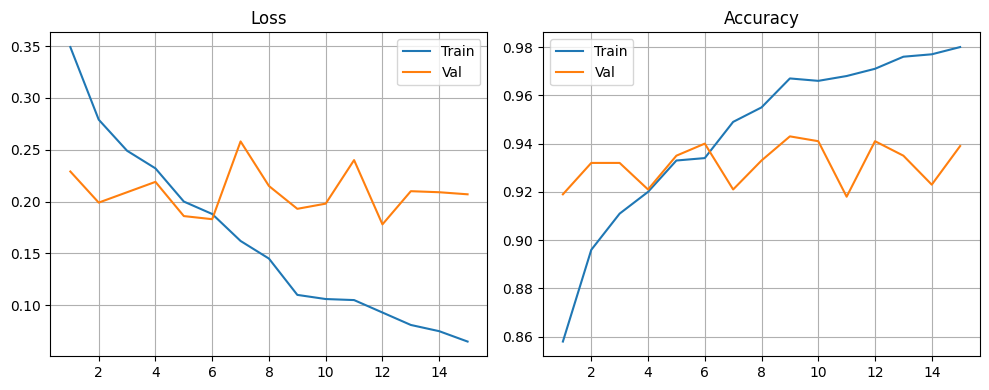

In [18]:
epochs = range(1,len(train_hist["loss"])+1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs,train_hist["loss"],label="Train")
plt.plot(epochs,val_hist["loss"],label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs,train_hist["accuracy"],label="Train")
plt.plot(epochs,val_hist["accuracy"],label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [19]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)

        all_preds.append(out)
        all_labels.append(y)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

pred_classes = torch.argmax(all_preds, dim=1)

# Classification Report (3 decimal precision)
report = classification_report(
    all_labels.cpu(),
    pred_classes.cpu(),
    target_names=CLASSES,
    digits=3
)

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      benign      0.901     0.948     0.924       500
   malignant      0.945     0.896     0.920       500

    accuracy                          0.922      1000
   macro avg      0.923     0.922     0.922      1000
weighted avg      0.923     0.922     0.922      1000



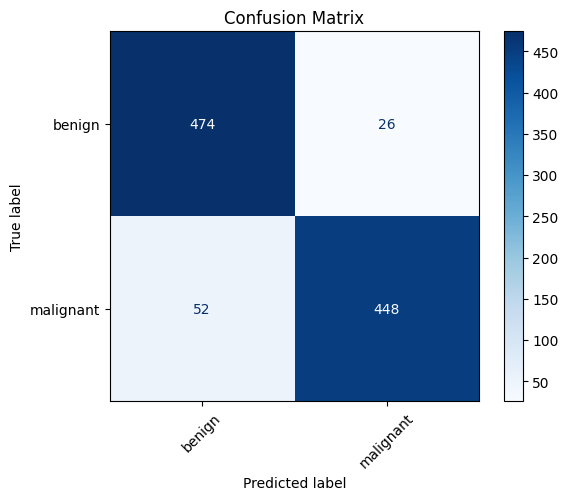

In [20]:
cm = confusion_matrix(all_labels.cpu(), pred_classes.cpu())

disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

In [21]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("\n" + "="*40)
print(f"{'Total Parameters:':<25} {total_params:,}")
print(f"{'Trainable Parameters:':<25} {trainable_params:,}")
print(f"{'Frozen Parameters:':<25} {frozen_params:,}")
print("="*40)


Total Parameters:         2,471,596
Trainable Parameters:     2,340,780
Frozen Parameters:        130,816
